# Stage 4: Traditional ML — Linear Regression From Scratch

Goal: implement gradient descent and linear regression in raw NumPy, understand *why* it converges, then confirm your version agrees with scikit-learn's.

Fill in each code cell yourself. Guiding questions are there to make you think before you code.

## 1. Load the data + first look

We'll use the California Housing dataset (built into scikit-learn, no download needed): `from sklearn.datasets import fetch_california_housing`.

Guiding questions:
- What are the features, and what's the target (`MedHouseVal`)?
- Any missing values or obviously weird ranges? (This dataset is cleaner than Titanic — Stage 3 skills still apply, just faster here.)
- What does the target's distribution look like — normal, skewed, anything to note?

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
import seaborn as sns

# TODO: load the dataset into a DataFrame (hint: fetch_california_housing(as_frame=True))
df = fetch_california_housing(as_frame=True)

data = df.frame







In [16]:
# TODO: .info(), .describe(), target distribution plot

data.info()
##data.describe()
data["MedHouseVal"].describe()

#sns.histplot(data["MedHouseVal"], kde=True)
#plt.show()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

## 2. Prep: select features, split, scale

To keep the from-scratch math manageable, start with just 2 features (e.g., `MedInc` and `AveRooms`) before using all of them. You can always redo Section 4 with more features once the mechanics are working.

Guiding questions:
- Why does gradient descent specifically (unlike some other algorithms) *require* scaled features to converge well? Think about what happens to the loss landscape when one feature ranges 0-15 and another ranges 0-30000.
- Split first, then fit the scaler on train only — same leakage rule as Stage 3.


Response:
- Graident descent needs scaled features to converge well because if we have large intervals of values, the information is skewed and may lean towards descending more because of a value just because it is high but not relatively high.



In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: select 2 features to start, split into train/val/test, fit scaler on train only


# Select features
X = data[["MedInc","AveRooms"]]
y = data["MedHouseVal"]

# Split into train+validation and test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Split train+validation into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1875,
    random_state=42
)



#Fit scaler on train only
scaler = StandardScaler()
scaler.fit(X_train)


# Transform all three using the scaler fitted on training data
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)




## 3. Implement linear regression from scratch

Build these pieces in order. Don't skip to the full training loop — implement and sanity-check each function individually first.

**3a. The hypothesis function**: `predict(X, w, b) = X @ w + b`

Guiding question: why is this just a dot product per row? What does `w` represent, geometrically, in terms of Stage 1's "vectors"?

Response:

This is just a dot product per row because each row of X represents a data point, and w represents a vector of weights (how strongly each feature contributes to the prediction -> the direction/orientation of the models prediction function a feature space), one for each feature.

In [29]:
def predict(X, w, b):
    return X @ w + b


**3b. The cost function**: Mean Squared Error — `(1/n) * sum((y_pred - y_true)^2)`

Guiding question: why squared error instead of just `(y_pred - y_true)`? (Two reasons — one about signs canceling out, one about the shape of the resulting loss landscape for gradient descent.)

Response:
- When we are given the errors (pos and neg) Those errors cancel eachother out making it seem like our model has no predictions errors which is false. Squaring the values heavily penalize the larger errors more. Additionally, squaring the values give us a parabola instead of a straight line which is intentionally useful for gradient descent where there is a clear global minimum

In [30]:
def compute_cost(X, y, w, b):
    y_pred = predict(X, w, b)
    y_true = y
    n = len(y)
    MSE = (1/n) * sum( (    y_pred - y_true            )**2)
    return MSE


**3c. The gradients**: partial derivatives of MSE with respect to `w` and `b`.

For MSE, these work out to:
- `dw = (2/n) * X.T @ (y_pred - y_true)`
- `db = (2/n) * sum(y_pred - y_true)`

Guiding question: don't just implement this — derive it by hand on paper first using the chain rule from your Stage 1 review (MSE is a function of `y_pred`, and `y_pred` is a function of `w`/`b`). This is where "understanding vs. copying" actually gets tested.

Response
- If y_pred changes then MSE(y) changes, and if (w/b) changes, then MSE(y) indirectly cahnges since y_pred depends on w/b since y = Xw + b


In [31]:
def compute_gradients(X, y, w, b):
    y_pred = predict(X,w,b)
    y_true = y
    n = len(y)
    dw = (2/n) * X.T @ (y_pred - y_true)
    db = (2/n) * sum(y_pred - y_true)
    return dw,db


**3d. The training loop**: repeatedly compute gradients and step `w`, `b` in the negative gradient direction, scaled by a learning rate.

Track the cost at every iteration so you can plot convergence afterward.

In [32]:
def train_linear_regression(X, y, learning_rate=0.01, n_iterations=1000):
    # TODO: initialize w, b (zeros is fine), loop n_iterations times:
    #   compute gradients, update w -= lr * dw, b -= lr * db, record cost
    # return final w, b, and the cost history list
    w = np.zeros(X.shape[1])
    b = 0
    cost = []
    for i in range(n_iterations):
        dw,db = compute_gradients(X,y,w,b)
        w-=learning_rate*dw
        b-=learning_rate*db
        current_cost = compute_cost(X, y, w, b)
        cost.append(current_cost)

    return w,b,cost


## 4. Train and plot the loss curve

Run training, then plot cost vs. iteration.

Guiding questions:
- Does the curve decrease smoothly and flatten out? If it's jumpy/diverging, what does that tell you about your learning rate?
- Try 2-3 different learning rates (e.g., 0.001, 0.01, 0.5) and plot all three curves together — what happens at each extreme?

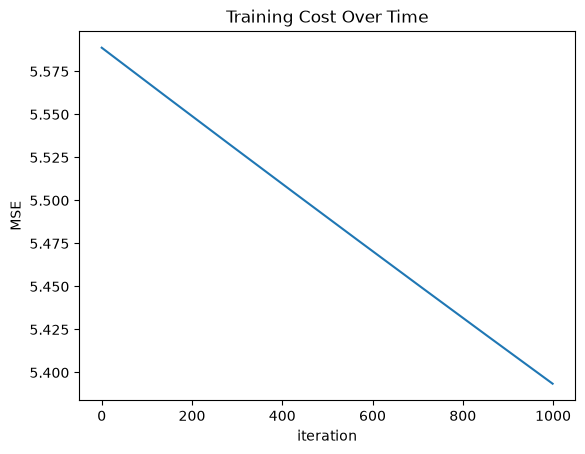

In [55]:
# TODO: train the model, plot cost history
w, b, cost = train_linear_regression(
    X_train_scaled,
    y_train,
    learning_rate=0.00001,
    n_iterations=1000
)

plt.plot(cost)
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("Training Cost Over Time")
plt.show()





## 5. Evaluate your from-scratch model

Implement MAE, RMSE, and R² yourself (don't import them yet) on the validation set. This forces you to actually understand what each metric computes rather than treating it as a black-box import.

Guiding question: in plain language, what does an R² of e.g. 0.6 actually mean about your model?

Response: 
- MAE: Mean Absolute Error -- on average,how far are my predictions from true values
- RSE: How far off am I, emphasizing big mistakes?
- R^2: How much variation in the target can my model explain?

In [34]:
def mae(y_true, y_pred):
    n = len(y_true)
    return (1 / n) * np.sum(np.abs(y_pred - y_true))


def rmse(y_true, y_pred):
    import math
    n = len(y_true)
    mse = (1 / n) * np.sum((y_pred - y_true) ** 2)
    return math.sqrt(mse)

def r_squared(y_true, y_pred):
    y_mean = np.mean(y_true)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_mean) ** 2)

    return 1 - (ss_res / ss_tot)

# TODO: evaluate your from-scratch model on the validation set
y_val_pred = predict(X_val_scaled, w, b)
val_mae = mae(y_val, y_val_pred)
val_rmse = rmse(y_val, y_val_pred)
val_r2 = r_squared(y_val, y_val_pred)

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)
print("Validation R²:", val_r2)





Validation MAE: 0.6277752806292947
Validation RMSE: 0.8672996970104316
Validation R²: 0.4573118515132053


## 6. Compare against scikit-learn

Fit `sklearn.linear_model.LinearRegression` on the same scaled train data.

Guiding questions:
- Do your `w`/`b` roughly match sklearn's `.coef_`/`.intercept_`? Small differences are fine (sklearn uses a closed-form solution, not gradient descent, by default) — but they should be in the same ballpark.
- Do the MAE/RMSE/R² scores roughly agree with your from-scratch metrics?

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TODO: fit sklearn's LinearRegression, compare coefficients and metrics to your from-scratch version

model = LinearRegression()
model.fit(X_train_scaled,y_train)
y_val_pred_sklearn = model.predict(X_val_scaled)

val_mae = mean_absolute_error(y_val, y_val_pred_sklearn)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_sklearn))
val_r2 = r2_score(y_val, y_val_pred_sklearn)

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)
print("Validation R²:", val_r2)





Validation MAE: 0.6277751480391354
Validation RMSE: 0.8673001840624479
Validation R²: 0.45731124199510653


## 7. Scale up: use all features

Redo the split/scale/train/evaluate steps using all available features instead of just 2, with scikit-learn this time (no need to redo the from-scratch version for more features — the mechanics are proven).

Guiding question: did R² improve with more features? Did MAE/RMSE? Any features you'd suspect are adding noise rather than signal?

In [49]:
# TODO: full-feature pipeline: split, scale, train, evaluate

#data.info()


# Select features
X = data[["MedInc",
          "AveRooms",
          "HouseAge",
          "AveBedrms",
          "Population",
          "AveOccup",
          "Latitude",
          "Longitude"
          ]]
y = data["MedHouseVal"]

# Split into train+validation and test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Split train+validation into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1875,
    random_state=42
)



#Fit scaler on train only
scaler = StandardScaler()
scaler.fit(X_train)


# Transform all three using the scaler fitted on training data
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)




model = LinearRegression()
model.fit(X_train_scaled,y_train)
y_val_pred_sklearn = model.predict(X_val_scaled)

val_mae = mean_absolute_error(y_val, y_val_pred_sklearn)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_sklearn))
val_r2 = r2_score(y_val, y_val_pred_sklearn)

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)
print("Validation R²:", val_r2)





Validation MAE: 0.5402252793788618
Validation RMSE: 0.733565334774117
Validation R²: 0.6117695919386561


In [50]:
y_test_pred = model.predict(X_test_scaled)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test MAE: 0.5334187099616101
Test RMSE: 0.7435192292671167
Test R²: 0.5781310617757847


## 8. Wrap-up

Write a short summary:
- Did your from-scratch gradient descent converge to results matching sklearn's closed-form solution?
- What did changing the learning rate teach you about the tradeoffs in choosing one?
- What do your final MAE/RMSE/R² numbers mean in plain-English terms about how good this model actually is at predicting house prices?

_Your summary here._

- My from scratch gradient descent does converge to results similar to sklearn's close-form solution.
- The learning rate controls how big of a step gradient descent takes when updating parameters (w,b), a small learning rate is stable and consistent and less likely to overshoot but it is slow. A large learning rate allows us to converge faster but risk of overshooting
- The model is DECENT in predicting house prices given the 8 features.
    - MSE: The model's predictions are off by about 0.54 target units on average.
    - RMSE: The typical error is around $54k, but larger mistakes pull the error toward ~$73k when weighted more heavily.
    - The eight features allow this linear model to explain about 61% of the differences in house prices.
